In [24]:
import os
import sys
import time
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [25]:
# Set plotting style
sns.set_theme(style="whitegrid")

In [26]:
project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.append(project_root)

In [27]:
from src.decision_tree import DecisionTreeRegressor
from src.bagging import BaggingRegressor
from src.random_forest import RandomForestRegressor
from src.xgboost import XGBoostRegressor

In [28]:
test_path = os.path.join(project_root, 'data', 'test.csv')
df_test = pd.read_csv(test_path)

In [29]:
target_col = 'Calories'
X_test = df_test.drop(target_col, axis=1)
y_test = df_test[target_col]

In [30]:
model_files = {
    "Decision Tree": "scratch_decision_tree.pkl",       
    "Bagging": "scratch_bagging.pkl",         
    "Random Forest": "scratch_randomforest.pkl",       
    "XGBoost": "scratch_xgboost.pkl"   
}

In [31]:
results_list = []

for model_name, filename in model_files.items():
    filepath = os.path.join('models', filename)
    if not os.path.exists(filepath):
        print(f" Warning: Could not find file for {model_name} at {filepath}. Skipping.")
        continue
        
    print(f"Evaluating: {model_name}...")
    
    try:
        # Load model
        model = joblib.load(filepath)
        
        # 1. Prepare Data based on Model Type
        if model_name == "XGBoost":
            # Your XGBoost needs the DataFrame to access column names/structure
            input_data = X_test 
        else:
            # DT, RF, and Bagging were built on raw NumPy arrays
            input_data = X_test.values 
            
        # 2. Predict using the correct input format
        start_time = time.time()
        preds = model.predict(input_data)
        end_time = time.time()
        runtime_sec = end_time - start_time

        # Calculate Metrics
        rmse = np.sqrt(mean_squared_error(y_test, preds))
        mae = mean_absolute_error(y_test, preds)
        r2 = r2_score(y_test, preds)

        # Save Results
        results_list.append({
            "Model": model_name,
            "RMSE": rmse,
            "MAE": mae,
            "R2 Score": r2,
            "Prediction Runtime (s)": runtime_sec
        })
    except Exception as e:
        print(f"An error occurred evaluating {model_name}: {e}")

print("\nEvaluation complete.")

Evaluating: Decision Tree...
Evaluating: Bagging...
Evaluating: Random Forest...
Evaluating: XGBoost...

Evaluation complete.


In [32]:
# Display Results Table
results_df = pd.DataFrame(results_list)

# Sort by RMSE (lower is better)
results_df = results_df.sort_values(by="RMSE", ascending=True).reset_index(drop=True)

results_df

,Model,RMSE,MAE,R2 Score,Prediction Runtime (s)
0,XGBoost,2.197576,1.547234,0.998803,0.766290
1,Bagging,2.771240,1.803253,0.998097,4.024797
2,Decision Tree,5.562466,3.601778,0.992333,0.008761
3,Random Forest,5.843829,4.127770,0.991538,1.922528


C:\Users\User\AppData\Local\Temp\ipykernel_22644\1403644393.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="Model", y="RMSE", ax=axes[0, 0], palette="viridis")
C:\Users\User\AppData\Local\Temp\ipykernel_22644\1403644393.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="Model", y="MAE", ax=axes[0, 1], palette="viridis")
C:\Users\User\AppData\Local\Temp\ipykernel_22644\1403644393.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="Model", y="R2 Score", ax=axes[1, 0], palette="

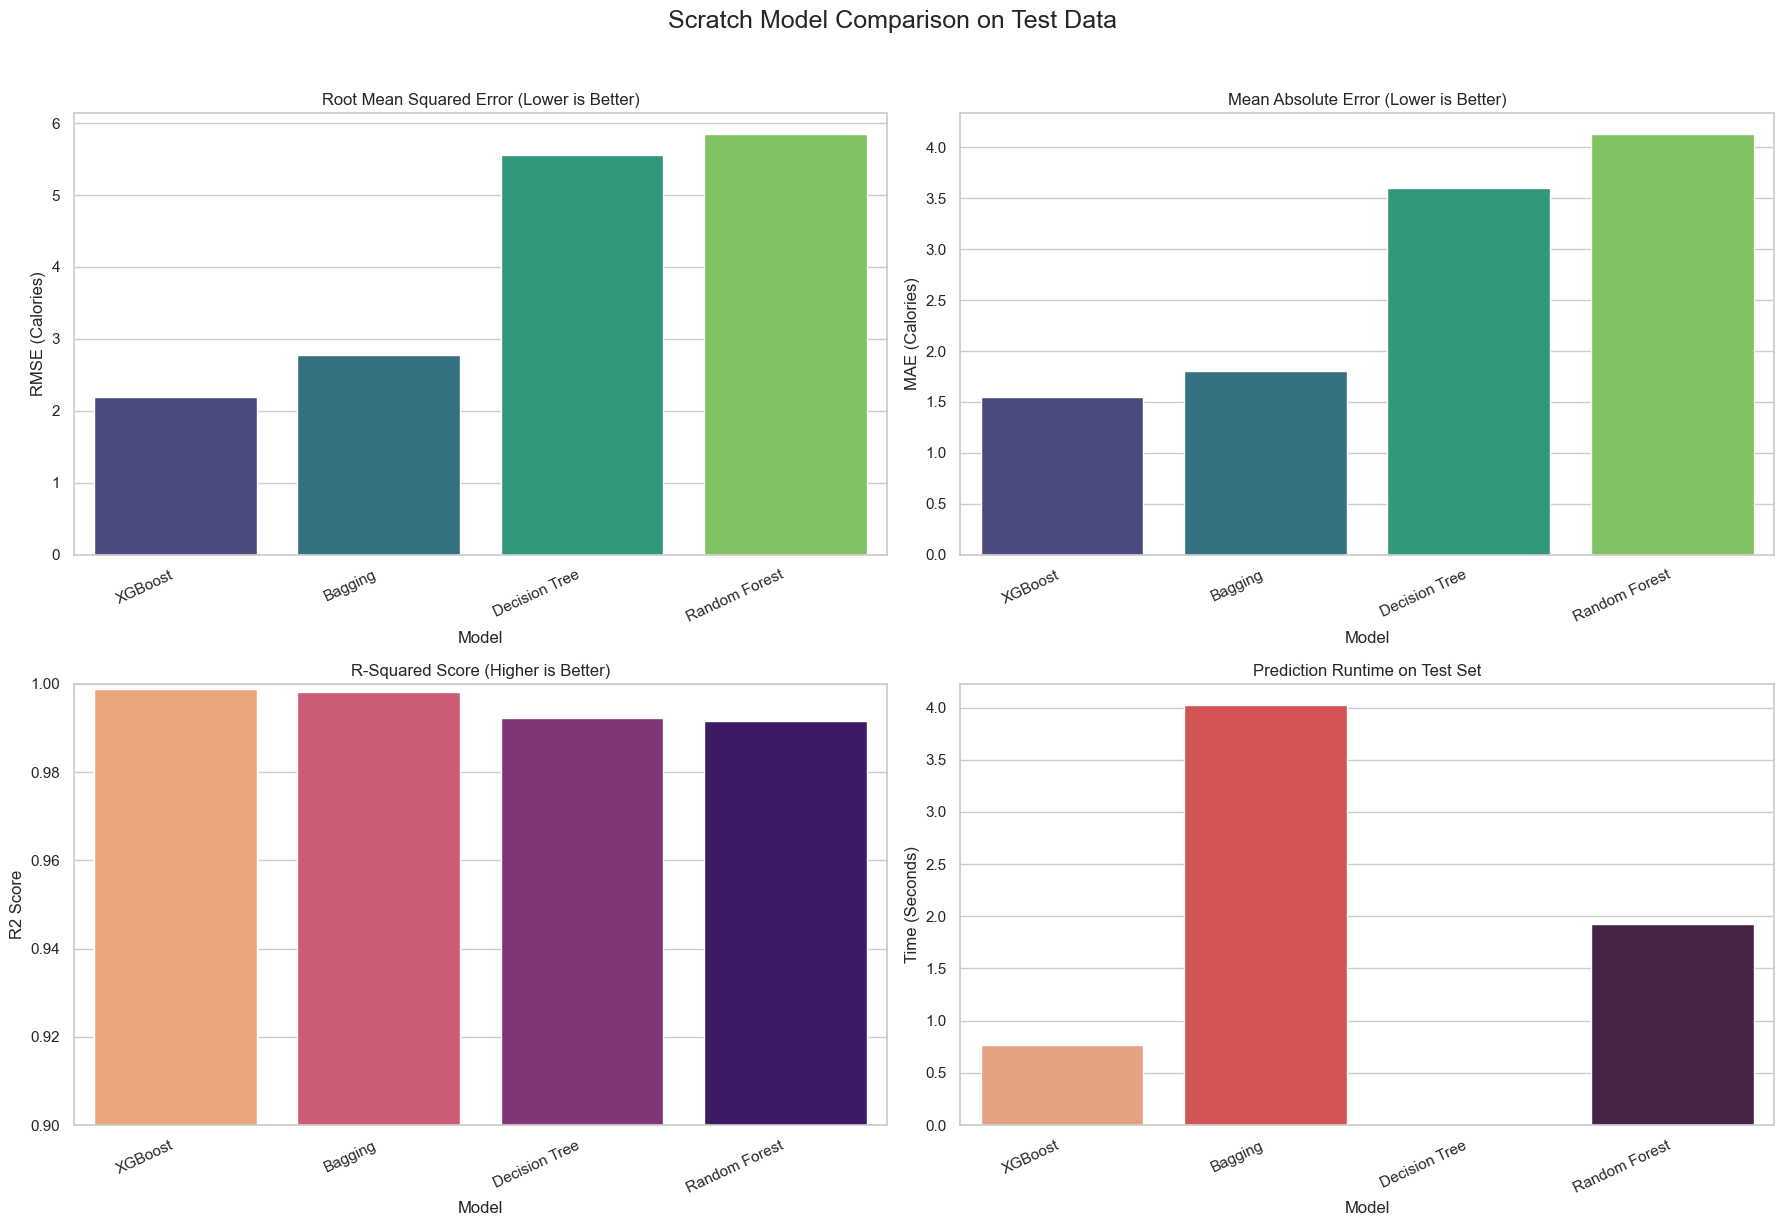

In [33]:
# Data Visualization

# Create a 2x2 grid of plots
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Scratch Model Comparison on Test Data', fontsize=18, y=1.02)

# Plot RMSE (Lower is better)
sns.barplot(data=results_df, x="Model", y="RMSE", ax=axes[0, 0], palette="viridis")
axes[0, 0].set_title("Root Mean Squared Error (Lower is Better)")
axes[0, 0].set_ylabel("RMSE (Calories)")

# Plot MAE (Lower is better)
sns.barplot(data=results_df, x="Model", y="MAE", ax=axes[0, 1], palette="viridis")
axes[0, 1].set_title("Mean Absolute Error (Lower is Better)")
axes[0, 1].set_ylabel("MAE (Calories)")

# Plot R2 (Higher is better)
sns.barplot(data=results_df, x="Model", y="R2 Score", ax=axes[1, 0], palette="magma_r")
axes[1, 0].set_title("R-Squared Score (Higher is Better)")
axes[1, 0].set_ylim(0.9, 1.0) # Zoom in as scores are likely high
axes[1, 0].set_ylabel("R2 Score")

# Plot Runtime (Lower is better)
sns.barplot(data=results_df, x="Model", y="Prediction Runtime (s)", ax=axes[1, 1], palette="rocket_r")
axes[1, 1].set_title("Prediction Runtime on Test Set")
axes[1, 1].set_ylabel("Time (Seconds)")

for ax in axes.flat:
    plt.setp(ax.get_xticklabels(), rotation=25, horizontalalignment='right')

plt.tight_layout()
plt.show()